## 3. Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')


In [2]:
from src.data.load import load_ieee, load_paysim

df_ieee   = load_ieee()
df_paysim = load_paysim()

print(f"\nIEEE-CIS:  {df_ieee.shape[0]:,} rows")
print(f"PaySim:    {df_paysim.shape[0]:,} rows")

正在读取 train_transaction.csv ...
正在读取 train_identity.csv ...
正在合并 ...
合并完成：590,540 行，434 列
欺诈比例：3.499%
正在读取 paysim.csv ...
读取完成：6,362,620 行，11 列
欺诈比例：0.129%

IEEE-CIS:  590,540 rows
PaySim:    6,362,620 rows


In [3]:
# ── IEEE-CIS ──────────────────────────────────────────────
ieee_split_idx = int(len(df_ieee) * 0.8)
ieee_train = df_ieee.iloc[:ieee_split_idx].copy()
ieee_test  = df_ieee.iloc[ieee_split_idx:].copy()

print("=== IEEE-CIS Split ===")
print(f"Train: {len(ieee_train):,} rows | TransactionDT up to {ieee_train['TransactionDT'].max()}")
print(f"  Fraud rate: {ieee_train['isFraud'].mean()*100:.3f}%")
print(f"Test:  {len(ieee_test):,} rows  | TransactionDT from {ieee_test['TransactionDT'].min()}")
print(f"  Fraud rate: {ieee_test['isFraud'].mean()*100:.3f}%")

# ── PaySim ────────────────────────────────────────────────
paysim_split_idx = int(len(df_paysim) * 0.8)
paysim_train = df_paysim.iloc[:paysim_split_idx].copy()
paysim_test  = df_paysim.iloc[paysim_split_idx:].copy()

print("\n=== PaySim Split ===")
print(f"Train: {len(paysim_train):,} rows | step up to {paysim_train['step'].max()}")
print(f"  Fraud rate: {paysim_train['isFraud'].mean()*100:.3f}%")
print(f"Test:  {len(paysim_test):,} rows  | step from {paysim_test['step'].min()}")
print(f"  Fraud rate: {paysim_test['isFraud'].mean()*100:.3f}%")

=== IEEE-CIS Split ===
Train: 472,432 rows | TransactionDT up to 12192842
  Fraud rate: 3.514%
Test:  118,108 rows  | TransactionDT from 12192900
  Fraud rate: 3.441%

=== PaySim Split ===
Train: 5,090,096 rows | step up to 355
  Fraud rate: 0.078%
Test:  1,272,524 rows  | step from 355
  Fraud rate: 0.334%


### 1. IEEE-CIS 时间特征

In [4]:
# 在 train 和 test 上分别提取，不涉及跨集信息，安全
for df_split in [ieee_train, ieee_test]:
    # 小时（0-23）
    df_split['hour'] = (df_split['TransactionDT'] // 3600) % 24
    # 星期几（0-6）
    df_split['day_of_week'] = (df_split['TransactionDT'] // 86400) % 7
    # 是否是深夜（EDA 里看到凌晨欺诈率高）
    df_split['is_night'] = df_split['hour'].between(0, 8).astype(int)

print("=== Time Features Sample ===")
print(ieee_train[['TransactionDT', 'hour', 'day_of_week', 'is_night']].head(10))

print("\n=== Fraud Rate by is_night ===")
for df_split, name in [(ieee_train, 'Train'), (ieee_test, 'Test')]:
    night_fraud = df_split.groupby('is_night')['isFraud'].mean() * 100
    print(f"{name}: daytime={night_fraud[0]:.2f}%  nighttime={night_fraud[1]:.2f}%")

=== Time Features Sample ===
   TransactionDT  hour  day_of_week  is_night
0          86400     0            1         1
1          86401     0            1         1
2          86469     0            1         1
3          86499     0            1         1
4          86506     0            1         1
5          86510     0            1         1
6          86522     0            1         1
7          86529     0            1         1
8          86535     0            1         1
9          86536     0            1         1

=== Fraud Rate by is_night ===
Train: daytime=3.26%  nighttime=4.19%
Test: daytime=3.14%  nighttime=4.43%


时间特征验证成功：夜间欺诈率（4.19%）明显高于白天（3.26%），和 EDA 的发现完全一致，而且 train 和 test 的规律方向一致，说明这个特征是稳定的 ✓

### 2. IEEE-CIS 聚合特征（最重要，也最需要小心泄露）

In [5]:
# 所有聚合都在完整时间序列上计算（train+test concat），
# 但每行只能看到它之前的数据，所以不存在泄露
df_all_ieee = pd.concat([ieee_train, ieee_test]).sort_values('TransactionDT').reset_index(drop=True)

# card1 维度的历史统计
print("Computing card1 aggregation features...")
df_all_ieee['card1_tx_count'] = (
    df_all_ieee.groupby('card1')['TransactionAmt']
    .transform(lambda x: x.shift(1).expanding().count())
)
df_all_ieee['card1_amt_mean'] = (
    df_all_ieee.groupby('card1')['TransactionAmt']
    .transform(lambda x: x.shift(1).expanding().mean())
)
df_all_ieee['card1_amt_std'] = (
    df_all_ieee.groupby('card1')['TransactionAmt']
    .transform(lambda x: x.shift(1).expanding().std())
)

# 消费偏离度：当前金额 vs 该卡历史均值
df_all_ieee['amt_vs_card1_mean'] = (
    df_all_ieee['TransactionAmt'] / (df_all_ieee['card1_amt_mean'] + 1)
)

print("Computing P_emaildomain aggregation features...")
df_all_ieee['email_tx_count'] = (
    df_all_ieee.groupby('P_emaildomain')['TransactionAmt']
    .transform(lambda x: x.shift(1).expanding().count())
)
df_all_ieee['email_fraud_mean'] = (
    df_all_ieee.groupby('P_emaildomain')['isFraud']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# 切回 train / test（按原始行数）
ieee_train_fe = df_all_ieee.iloc[:len(ieee_train)].copy()
ieee_test_fe  = df_all_ieee.iloc[len(ieee_train):].copy()

print("\n=== New Features Sample (train) ===")
cols = ['TransactionAmt', 'card1_tx_count', 'card1_amt_mean', 
        'card1_amt_std', 'amt_vs_card1_mean', 'email_fraud_mean']
print(ieee_train_fe[cols].head(10).to_string())

print("\n=== Missing Values in New Features ===")
new_cols = ['card1_tx_count', 'card1_amt_mean', 'card1_amt_std', 
            'amt_vs_card1_mean', 'email_tx_count', 'email_fraud_mean']
print(ieee_train_fe[new_cols].isnull().sum())

Computing card1 aggregation features...
Computing P_emaildomain aggregation features...

=== New Features Sample (train) ===
   TransactionAmt  card1_tx_count  card1_amt_mean  card1_amt_std  amt_vs_card1_mean  email_fraud_mean
0            68.5             0.0             NaN            NaN                NaN               NaN
1            29.0             0.0             NaN            NaN                NaN               NaN
2            59.0             0.0             NaN            NaN                NaN               NaN
3            50.0             0.0             NaN            NaN                NaN               NaN
4            50.0             0.0             NaN            NaN                NaN               0.0
5            49.0             0.0             NaN            NaN                NaN               0.0
6           159.0             0.0             NaN            NaN                NaN               0.0
7           422.5             0.0             NaN          

In [6]:
# count 类：第一次出现 → 历史为 0 次（已经是0，无需处理）
# mean 类：第一次出现 → 用全局中位数填充
# std 类：第一次出现或只有1条记录 → 用 0 填充（无偏差）
# ratio 类：无历史均值 → 用 1 填充（表示"与平均水平持平"）
# email 类：无邮件域名 → 用 0 填充

# 用 train 的统计量来填充（fit on train，transform on both）
card1_amt_mean_global = ieee_train_fe['card1_amt_mean'].median()

for df_split in [ieee_train_fe, ieee_test_fe]:
    df_split['card1_amt_mean']      = df_split['card1_amt_mean'].fillna(card1_amt_mean_global)
    df_split['card1_amt_std']       = df_split['card1_amt_std'].fillna(0)
    df_split['amt_vs_card1_mean']   = df_split['amt_vs_card1_mean'].fillna(1)
    df_split['email_tx_count']      = df_split['email_tx_count'].fillna(0)
    df_split['email_fraud_mean']    = df_split['email_fraud_mean'].fillna(0)

print("=== Missing Values After Fill ===")
new_cols = ['card1_tx_count', 'card1_amt_mean', 'card1_amt_std',
            'amt_vs_card1_mean', 'email_tx_count', 'email_fraud_mean']
print("Train:")
print(ieee_train_fe[new_cols].isnull().sum())
print("\nTest:")
print(ieee_test_fe[new_cols].isnull().sum())

print(f"\ncard1_amt_mean fill value (train median): {card1_amt_mean_global:.2f}")

=== Missing Values After Fill ===
Train:
card1_tx_count       0
card1_amt_mean       0
card1_amt_std        0
amt_vs_card1_mean    0
email_tx_count       0
email_fraud_mean     0
dtype: int64

Test:
card1_tx_count       0
card1_amt_mean       0
card1_amt_std        0
amt_vs_card1_mean    0
email_tx_count       0
email_fraud_mean     0
dtype: int64

card1_amt_mean fill value (train median): 115.01


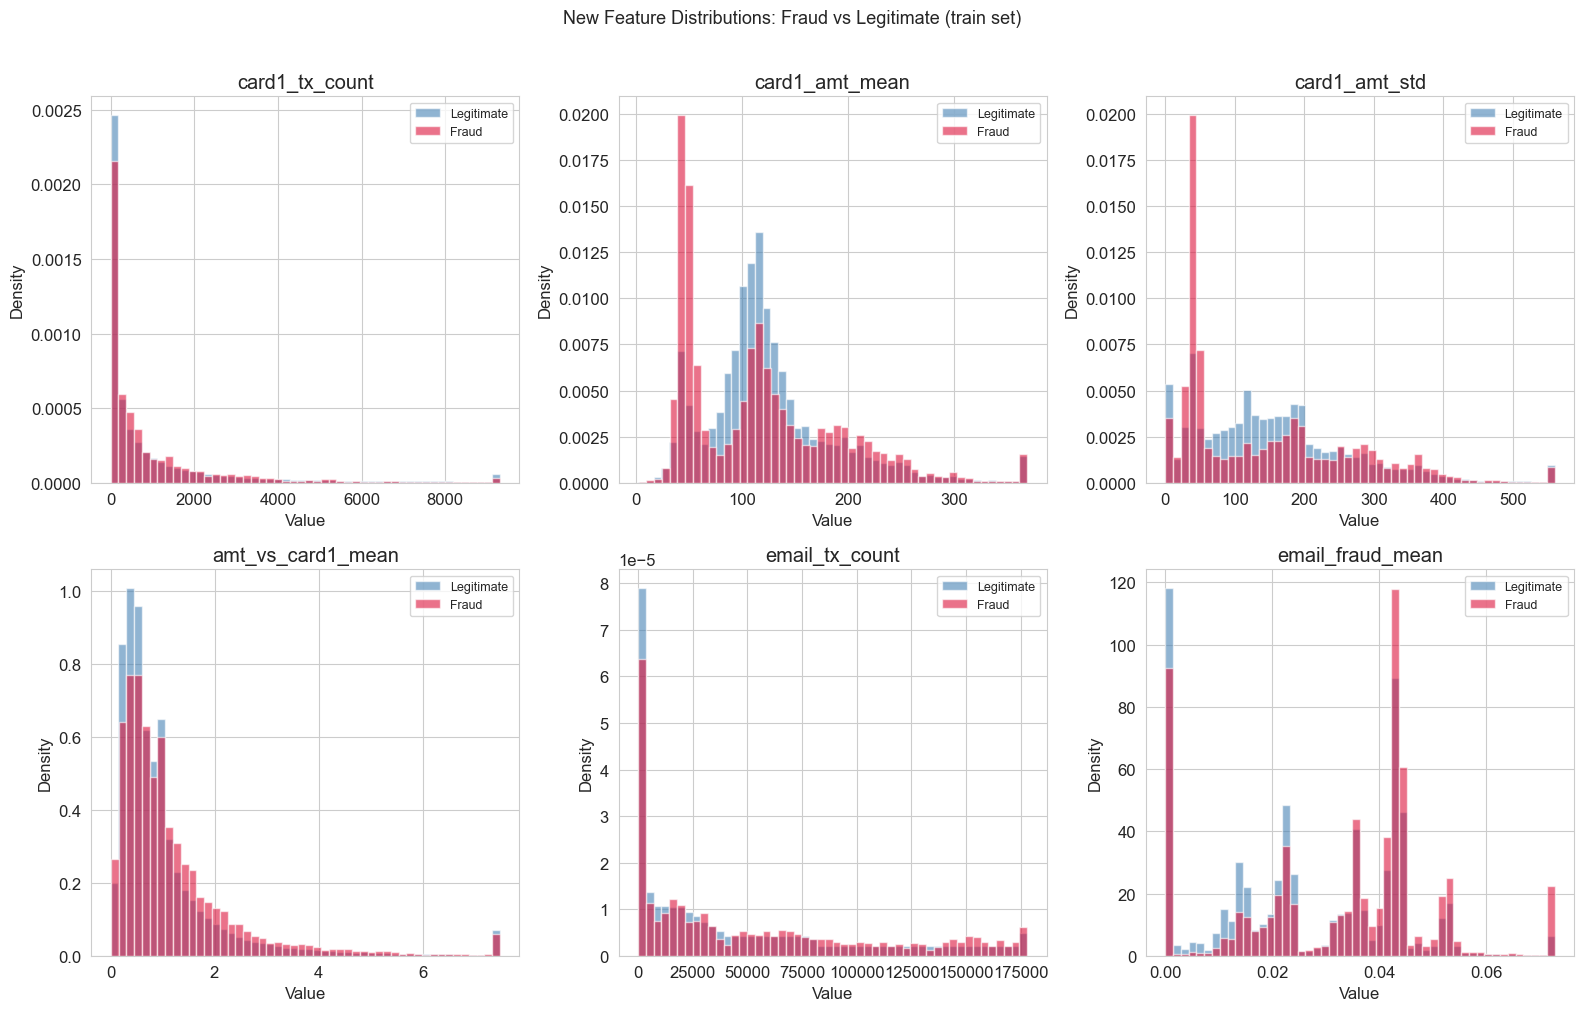

=== Mean values by class (train) ===
isFraud                    0          1
card1_tx_count      1018.716    993.180
card1_amt_mean       127.728    118.624
card1_amt_std        157.882    146.376
amt_vs_card1_mean      1.079      1.235
email_tx_count     45006.286  54484.640
email_fraud_mean       0.027      0.034


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features = ['card1_tx_count', 'card1_amt_mean', 'card1_amt_std',
            'amt_vs_card1_mean', 'email_tx_count', 'email_fraud_mean']

for i, feat in enumerate(features):
    fraud_vals  = ieee_train_fe[ieee_train_fe['isFraud']==1][feat]
    legit_vals  = ieee_train_fe[ieee_train_fe['isFraud']==0][feat]
    
    # clip 极端值方便可视化
    p99 = ieee_train_fe[feat].quantile(0.99)
    fraud_vals = fraud_vals.clip(upper=p99)
    legit_vals = legit_vals.clip(upper=p99)
    
    axes[i].hist(legit_vals, bins=50, alpha=0.6, color='steelblue', 
                 label='Legitimate', density=True)
    axes[i].hist(fraud_vals, bins=50, alpha=0.6, color='crimson',
                 label='Fraud', density=True)
    axes[i].set_title(feat)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.suptitle('New Feature Distributions: Fraud vs Legitimate (train set)', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("=== Mean values by class (train) ===")
print(ieee_train_fe.groupby('isFraud')[features].mean().round(3).T)

In [8]:
# 按 card1 分组，计算相邻两笔交易的时间间隔
print("Computing time delta features...")
df_all_ieee = df_all_ieee.sort_values('TransactionDT')

df_all_ieee['card1_time_delta'] = (
    df_all_ieee.groupby('card1')['TransactionDT']
    .transform(lambda x: x.diff())
)

# 该卡历史最大单笔金额
df_all_ieee['card1_amt_max'] = (
    df_all_ieee.groupby('card1')['TransactionAmt']
    .transform(lambda x: x.shift(1).expanding().max())
)

# 当前金额是否超过该卡历史最大值
df_all_ieee['amt_exceeds_max'] = (
    (df_all_ieee['TransactionAmt'] > df_all_ieee['card1_amt_max']).astype(int)
)

# addr1 维度的欺诈历史均值（billing address）
df_all_ieee['addr1_fraud_mean'] = (
    df_all_ieee.groupby('addr1')['isFraud']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# 切回 train / test
ieee_train_fe = df_all_ieee.iloc[:len(ieee_train)].copy()
ieee_test_fe  = df_all_ieee.iloc[len(ieee_train):].copy()

# 填充缺失值
for df_split in [ieee_train_fe, ieee_test_fe]:
    df_split['card1_time_delta'] = df_split['card1_time_delta'].fillna(-1)
    df_split['card1_amt_max']    = df_split['card1_amt_max'].fillna(
        ieee_train_fe['card1_amt_max'].median()
    )
    df_split['amt_exceeds_max']  = df_split['amt_exceeds_max'].fillna(0)
    df_split['addr1_fraud_mean'] = df_split['addr1_fraud_mean'].fillna(0)

print("=== Mean values by class (train) ===")
new_feats = ['card1_time_delta', 'card1_amt_max', 'amt_exceeds_max', 'addr1_fraud_mean']
print(ieee_train_fe.groupby('isFraud')[new_feats].mean().round(3).T)

Computing time delta features...
=== Mean values by class (train) ===
isFraud                    0          1
card1_time_delta  147423.239  98552.861
card1_amt_max       1659.189   1532.834
amt_exceeds_max        0.033      0.031
addr1_fraud_mean       0.020      0.020


In [9]:
# 我们确认保留的工程特征
engineered_features = [
    # 时间特征
    'hour',
    'day_of_week', 
    'is_night',
    # card1 聚合特征
    'card1_tx_count',
    'card1_amt_mean',
    'card1_amt_std',
    'card1_time_delta',
    # 偏离度特征
    'amt_vs_card1_mean',
    # 邮件域名特征
    'email_tx_count',
    'email_fraud_mean',
]

print("=== Final Engineered Features ===")
for i, f in enumerate(engineered_features, 1):
    print(f"  {i:2d}. {f}")

print(f"\nTotal engineered features: {len(engineered_features)}")

print("\n=== Verification: no NaN in any engineered feature ===")
for df_split, name in [(ieee_train_fe, 'Train'), (ieee_test_fe, 'Test')]:
    null_counts = df_split[engineered_features].isnull().sum()
    total_nulls = null_counts.sum()
    print(f"{name}: {total_nulls} total NaN values {'✓' if total_nulls == 0 else '✗'}")

=== Final Engineered Features ===
   1. hour
   2. day_of_week
   3. is_night
   4. card1_tx_count
   5. card1_amt_mean
   6. card1_amt_std
   7. card1_time_delta
   8. amt_vs_card1_mean
   9. email_tx_count
  10. email_fraud_mean

Total engineered features: 10

=== Verification: no NaN in any engineered feature ===
Train: 194771 total NaN values ✗
Test: 44968 total NaN values ✗


In [10]:
card1_amt_mean_global = ieee_train_fe['card1_amt_mean'].median()
card1_amt_max_global  = ieee_train_fe['card1_amt_max'].median()

for df_split in [ieee_train_fe, ieee_test_fe]:
    # Cell 5 的特征
    df_split['card1_amt_mean']     = df_split['card1_amt_mean'].fillna(card1_amt_mean_global)
    df_split['card1_amt_std']      = df_split['card1_amt_std'].fillna(0)
    df_split['amt_vs_card1_mean']  = df_split['amt_vs_card1_mean'].fillna(1)
    df_split['email_tx_count']     = df_split['email_tx_count'].fillna(0)
    df_split['email_fraud_mean']   = df_split['email_fraud_mean'].fillna(0)
    # Cell 8 的特征
    df_split['card1_time_delta']   = df_split['card1_time_delta'].fillna(-1)
    df_split['card1_amt_max']      = df_split['card1_amt_max'].fillna(card1_amt_max_global)
    df_split['amt_exceeds_max']    = df_split['amt_exceeds_max'].fillna(0)
    df_split['addr1_fraud_mean']   = df_split['addr1_fraud_mean'].fillna(0)

print("=== Verification after unified fillna ===")
for df_split, name in [(ieee_train_fe, 'Train'), (ieee_test_fe, 'Test')]:
    null_counts = df_split[engineered_features].isnull().sum()
    total_nulls = null_counts.sum()
    print(f"{name}: {total_nulls} total NaN values {'✓' if total_nulls == 0 else '✗'}")
    if total_nulls > 0:
        print(df_split[engineered_features].isnull().sum()[lambda x: x > 0])

=== Verification after unified fillna ===
Train: 0 total NaN values ✓
Test: 0 total NaN values ✓


In [11]:
print("Computing PaySim features...")

df_all_paysim = pd.concat([paysim_train, paysim_test]).sort_values('step').reset_index(drop=True)

# 1. 交易类型是否为高风险（EDA发现只有TRANSFER和CASH_OUT有欺诈）
df_all_paysim['is_high_risk_type'] = (
    df_all_paysim['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)
)

# 2. 余额差异（EDA发现欺诈时接近0）
df_all_paysim['balance_diff_orig'] = (
    df_all_paysim['oldbalanceOrg'] - df_all_paysim['newbalanceOrig'] - df_all_paysim['amount']
)

# 3. 发起方账户余额是否被清空
df_all_paysim['orig_balance_zero'] = (
    df_all_paysim['newbalanceOrig'] == 0
).astype(int)

# 4. 金额占发起方原始余额的比例
df_all_paysim['amt_to_balance_ratio'] = (
    df_all_paysim['amount'] / (df_all_paysim['oldbalanceOrg'] + 1)
)

# 5. 每个账户的历史交易次数（只看过去）
df_all_paysim['orig_tx_count'] = (
    df_all_paysim.groupby('nameOrig')['amount']
    .transform(lambda x: x.shift(1).expanding().count())
).fillna(0)

# 6. 每个账户的历史平均金额
df_all_paysim['orig_amt_mean'] = (
    df_all_paysim.groupby('nameOrig')['amount']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# 切回 train / test
paysim_train_fe = df_all_paysim.iloc[:len(paysim_train)].copy()
paysim_test_fe  = df_all_paysim.iloc[len(paysim_train):].copy()

# 填充
orig_amt_mean_global = paysim_train_fe['orig_amt_mean'].median()
for df_split in [paysim_train_fe, paysim_test_fe]:
    df_split['orig_amt_mean'] = df_split['orig_amt_mean'].fillna(orig_amt_mean_global)

print("=== Mean values by class (train) ===")
paysim_features = ['is_high_risk_type', 'balance_diff_orig', 'orig_balance_zero',
                   'amt_to_balance_ratio', 'orig_tx_count', 'orig_amt_mean']
print(paysim_train_fe.groupby('isFraud')[paysim_features].mean().round(3).T)

print("\n=== NaN check ===")
for df_split, name in [(paysim_train_fe, 'Train'), (paysim_test_fe, 'Test')]:
    total_nulls = df_split[paysim_features].isnull().sum().sum()
    print(f"{name}: {total_nulls} NaN values {'✓' if total_nulls == 0 else '✗'}")

Computing PaySim features...
=== Mean values by class (train) ===
isFraud                        0          1
is_high_risk_type          0.437      1.000
balance_diff_orig    -203349.783  -4259.667
orig_balance_zero          0.568      0.988
amt_to_balance_ratio   72783.566   2409.456
orig_tx_count              0.001      0.002
orig_amt_mean          71372.476  71227.286

=== NaN check ===
Train: 0 NaN values ✓
Test: 0 NaN values ✓


In [12]:
from pathlib import Path

processed_dir = Path.cwd().parent / 'data' / 'processed'
processed_dir.mkdir(exist_ok=True)

# IEEE-CIS
ieee_train_fe.to_parquet(processed_dir / 'ieee_train.parquet', index=False)
ieee_test_fe.to_parquet(processed_dir  / 'ieee_test.parquet',  index=False)

# PaySim
paysim_train_fe.to_parquet(processed_dir / 'paysim_train.parquet', index=False)
paysim_test_fe.to_parquet(processed_dir  / 'paysim_test.parquet',  index=False)

# 保存特征列表，队友加载时直接用
import json

ieee_paysim_info = {
    'ieee': {
        'engineered_features': engineered_features,
        'target': 'isFraud',
        'time_col': 'TransactionDT',
        'train_rows': len(ieee_train_fe),
        'test_rows': len(ieee_test_fe),
        'train_fraud_rate': round(ieee_train_fe['isFraud'].mean(), 5),
        'test_fraud_rate': round(ieee_test_fe['isFraud'].mean(), 5),
    },
    'paysim': {
        'engineered_features': paysim_features,
        'target': 'isFraud',
        'time_col': 'step',
        'train_rows': len(paysim_train_fe),
        'test_rows': len(paysim_test_fe),
        'train_fraud_rate': round(paysim_train_fe['isFraud'].mean(), 5),
        'test_fraud_rate': round(paysim_test_fe['isFraud'].mean(), 5),
    }
}

with open(processed_dir / 'dataset_info.json', 'w') as f:
    json.dump(ieee_paysim_info, f, indent=2)

print("=== Saved Files ===")
for f in sorted(processed_dir.iterdir()):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"  {f.name:35s} {size_mb:.1f} MB")

print("\n=== Dataset Info ===")
print(json.dumps(ieee_paysim_info, indent=2))   

=== Saved Files ===
  dataset_info.json                   0.0 MB
  ieee_test.parquet                   23.5 MB
  ieee_train.parquet                  83.7 MB
  paysim_test.parquet                 71.1 MB
  paysim_train.parquet                277.7 MB
  pr_curve_fe_comparison.png          0.1 MB

=== Dataset Info ===
{
  "ieee": {
    "engineered_features": [
      "hour",
      "day_of_week",
      "is_night",
      "card1_tx_count",
      "card1_amt_mean",
      "card1_amt_std",
      "card1_time_delta",
      "amt_vs_card1_mean",
      "email_tx_count",
      "email_fraud_mean"
    ],
    "target": "isFraud",
    "time_col": "TransactionDT",
    "train_rows": 472432,
    "test_rows": 118108,
    "train_fraud_rate": 0.03514,
    "test_fraud_rate": 0.03441
  },
  "paysim": {
    "engineered_features": [
      "is_high_risk_type",
      "balance_diff_orig",
      "orig_balance_zero",
      "amt_to_balance_ratio",
      "orig_tx_count",
      "orig_amt_mean"
    ],
    "target": "isFraud"

In [13]:
# ── 改进1：构造 uid（card1 + addr1 近似用户ID）──────────
print("Computing uid features...")
df_all_ieee['uid'] = (
    df_all_ieee['card1'].astype(str) + '_' + 
    df_all_ieee['addr1'].fillna(-1).astype(str)
)

df_all_ieee['uid_tx_count'] = (
    df_all_ieee.groupby('uid')['TransactionAmt']
    .transform(lambda x: x.shift(1).expanding().count())
).fillna(0)

df_all_ieee['uid_amt_mean'] = (
    df_all_ieee.groupby('uid')['TransactionAmt']
    .transform(lambda x: x.shift(1).expanding().mean())
)

df_all_ieee['uid_fraud_mean'] = (
    df_all_ieee.groupby('uid')['isFraud']
    .transform(lambda x: x.shift(1).expanding().mean())
).fillna(0)

# ── 改进2：正确使用 D1（距上次交易天数）──────────────────
# D1 已经是现成特征，直接保留，不需要重新计算
# 但我们可以做一个"D1是否异常小"的二值特征
print("Computing D1 features...")
d1_threshold = df_all_ieee['D1'].quantile(0.1)  # 最快的10%
df_all_ieee['d1_is_fast'] = (df_all_ieee['D1'] < d1_threshold).astype(int)

# ── 改进3：频率编码高基数类别 ─────────────────────────────
print("Computing frequency encoding...")

# 只用 train 部分来计算频率，避免泄露
train_mask = df_all_ieee.index < len(ieee_train)

for col in ['card1', 'card2', 'P_emaildomain', 'R_emaildomain']:
    freq_map = df_all_ieee.loc[train_mask, col].value_counts().to_dict()
    df_all_ieee[f'{col}_freq'] = df_all_ieee[col].map(freq_map).fillna(0)

# ── 切回 train / test ─────────────────────────────────────
ieee_train_fe = df_all_ieee.iloc[:len(ieee_train)].copy()
ieee_test_fe  = df_all_ieee.iloc[len(ieee_train):].copy()

# 填充 uid_amt_mean
uid_amt_mean_global = ieee_train_fe['uid_amt_mean'].median()
for df_split in [ieee_train_fe, ieee_test_fe]:
    df_split['uid_amt_mean'] = df_split['uid_amt_mean'].fillna(uid_amt_mean_global)

# ── 更新特征列表 ──────────────────────────────────────────
engineered_features_v2 = engineered_features + [
    'uid_tx_count', 'uid_amt_mean', 'uid_fraud_mean',
    'd1_is_fast',
    'card1_freq', 'card2_freq', 'P_emaildomain_freq', 'R_emaildomain_freq'
]

print(f"\nTotal engineered features v2: {len(engineered_features_v2)}")

print("\n=== NaN check ===")
for df_split, name in [(ieee_train_fe, 'Train'), (ieee_test_fe, 'Test')]:
    total_nulls = df_split[engineered_features_v2].isnull().sum().sum()
    print(f"{name}: {total_nulls} NaN values {'✓' if total_nulls == 0 else '✗'}")

print("\n=== New features mean by class (train) ===")
new_only = ['uid_tx_count', 'uid_amt_mean', 'uid_fraud_mean', 
            'd1_is_fast', 'card1_freq']
print(ieee_train_fe.groupby('isFraud')[new_only].mean().round(3).T)

Computing uid features...
Computing D1 features...
Computing frequency encoding...

Total engineered features v2: 18

=== NaN check ===
Train: 207501 NaN values ✗
Test: 45791 NaN values ✗

=== New features mean by class (train) ===
isFraud                0         1
uid_tx_count     311.015   399.092
uid_amt_mean     125.630   117.959
uid_fraud_mean     0.022     0.206
d1_is_fast         0.000     0.000
card1_freq      2043.173  1857.138


In [14]:
# 查看哪些特征还有 NaN
print("=== NaN breakdown ===")
null_series = ieee_train_fe[engineered_features_v2].isnull().sum()
print(null_series[null_series > 0])

=== NaN breakdown ===
card1_amt_mean       12730
card1_amt_std        22080
card1_time_delta     12730
amt_vs_card1_mean    12730
email_tx_count       73586
email_fraud_mean     73645
dtype: int64


In [15]:
# 用 train 计算填充值（fit on train only）
fill_values = {
    'card1_amt_mean'    : ieee_train_fe['card1_amt_mean'].median(),
    'card1_amt_std'     : 0,
    'card1_time_delta'  : -1,
    'amt_vs_card1_mean' : 1,
    'email_tx_count'    : 0,
    'email_fraud_mean'  : 0,
    'uid_amt_mean'      : ieee_train_fe['uid_amt_mean'].median(),
    'uid_fraud_mean'    : 0,
    'uid_tx_count'      : 0,
    'd1_is_fast'        : 0,
    'card1_freq'        : 0,
    'card2_freq'        : 0,
    'P_emaildomain_freq': 0,
    'R_emaildomain_freq': 0,
}

for df_split in [ieee_train_fe, ieee_test_fe]:
    for col, val in fill_values.items():
        df_split[col] = df_split[col].fillna(val)

# 丢弃 d1_is_fast（两组均值都是0，无区分能力）
engineered_features_v2 = [f for f in engineered_features_v2 if f != 'd1_is_fast']

print("=== NaN check after unified fill ===")
for df_split, name in [(ieee_train_fe, 'Train'), (ieee_test_fe, 'Test')]:
    total_nulls = df_split[engineered_features_v2].isnull().sum().sum()
    print(f"{name}: {total_nulls} NaN values {'✓' if total_nulls == 0 else '✗'}")

print(f"\nFinal engineered features v2 ({len(engineered_features_v2)}):")
for i, f in enumerate(engineered_features_v2, 1):
    print(f"  {i:2d}. {f}")

=== NaN check after unified fill ===
Train: 0 NaN values ✓
Test: 0 NaN values ✓

Final engineered features v2 (17):
   1. hour
   2. day_of_week
   3. is_night
   4. card1_tx_count
   5. card1_amt_mean
   6. card1_amt_std
   7. card1_time_delta
   8. amt_vs_card1_mean
   9. email_tx_count
  10. email_fraud_mean
  11. uid_tx_count
  12. uid_amt_mean
  13. uid_fraud_mean
  14. card1_freq
  15. card2_freq
  16. P_emaildomain_freq
  17. R_emaildomain_freq


## XGBoost test Feature engineering

In [16]:
from sklearn.metrics import average_precision_score
import xgboost as xgb

# ── Label encode object 列 ────────────────────────────────
from sklearn.preprocessing import LabelEncoder

raw_features = [
    'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4',
    'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2',
    'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5',
    'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
    'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9'
]
raw_features = [c for c in raw_features if c in ieee_train_fe.columns]

for col in raw_features:
    if ieee_train_fe[col].dtype == 'object':
        le = LabelEncoder()
        combined = pd.concat([ieee_train_fe[col], ieee_test_fe[col]]).fillna('__missing__').astype(str)
        le.fit(combined)
        ieee_train_fe[col + '_enc'] = le.transform(ieee_train_fe[col].fillna('__missing__').astype(str))
        ieee_test_fe[col + '_enc']  = le.transform(ieee_test_fe[col].fillna('__missing__').astype(str))

raw_features_enc = [c + '_enc' if ieee_train_fe[c].dtype == 'object' else c for c in raw_features]

# ── 模型参数 ──────────────────────────────────────────────
xgb_params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=int((ieee_train_fe['isFraud']==0).sum() /
                         (ieee_train_fe['isFraud']==1).sum()),
    random_state=42,
    n_jobs=-1,
)

y_train = ieee_train_fe['isFraud']
y_test  = ieee_test_fe['isFraud']

# ── 实验 A：无特征工程 ────────────────────────────────────
print("Training A: WITHOUT feature engineering...")
X_train_raw = ieee_train_fe[raw_features_enc].fillna(-999)
X_test_raw  = ieee_test_fe[raw_features_enc].fillna(-999)
model_a = xgb.XGBClassifier(**xgb_params)
model_a.fit(X_train_raw, y_train, verbose=False)
pred_a  = model_a.predict_proba(X_test_raw)[:, 1]
auprc_a = average_precision_score(y_test, pred_a)
print(f"  AUPRC: {auprc_a:.4f}")

# ── 实验 B：v1 特征工程（10个特征）────────────────────────
print("\nTraining B: WITH feature engineering v1 (10 features)...")
full_features_v1 = raw_features_enc + engineered_features
X_train_v1 = ieee_train_fe[full_features_v1].fillna(-999)
X_test_v1  = ieee_test_fe[full_features_v1].fillna(-999)
model_b = xgb.XGBClassifier(**xgb_params)
model_b.fit(X_train_v1, y_train, verbose=False)
pred_b  = model_b.predict_proba(X_test_v1)[:, 1]
auprc_b = average_precision_score(y_test, pred_b)
print(f"  AUPRC: {auprc_b:.4f}")

# ── 实验 C：v2 特征工程（17个特征）────────────────────────
print("\nTraining C: WITH feature engineering v2 (17 features)...")
full_features_v2 = raw_features_enc + engineered_features_v2
X_train_v2 = ieee_train_fe[full_features_v2].fillna(-999)
X_test_v2  = ieee_test_fe[full_features_v2].fillna(-999)
model_c = xgb.XGBClassifier(**xgb_params)
model_c.fit(X_train_v2, y_train, verbose=False)
pred_c  = model_c.predict_proba(X_test_v2)[:, 1]
auprc_c = average_precision_score(y_test, pred_c)
print(f"  AUPRC: {auprc_c:.4f}")

# ── 汇总 ──────────────────────────────────────────────────
print("\n" + "="*50)
print(f"  A. No FE              AUPRC: {auprc_a:.4f}")
print(f"  B. FE v1 (10 feats)   AUPRC: {auprc_b:.4f}  (+{auprc_b-auprc_a:.4f})")
print(f"  C. FE v2 (17 feats)   AUPRC: {auprc_c:.4f}  (+{auprc_c-auprc_a:.4f})")
print("="*50)

Training A: WITHOUT feature engineering...
  AUPRC: 0.4901

Training B: WITH feature engineering v1 (10 features)...
  AUPRC: 0.4909

Training C: WITH feature engineering v2 (17 features)...
  AUPRC: 0.6082

  A. No FE              AUPRC: 0.4901
  B. FE v1 (10 feats)   AUPRC: 0.4909  (+0.0008)
  C. FE v2 (17 feats)   AUPRC: 0.6082  (+0.1181)


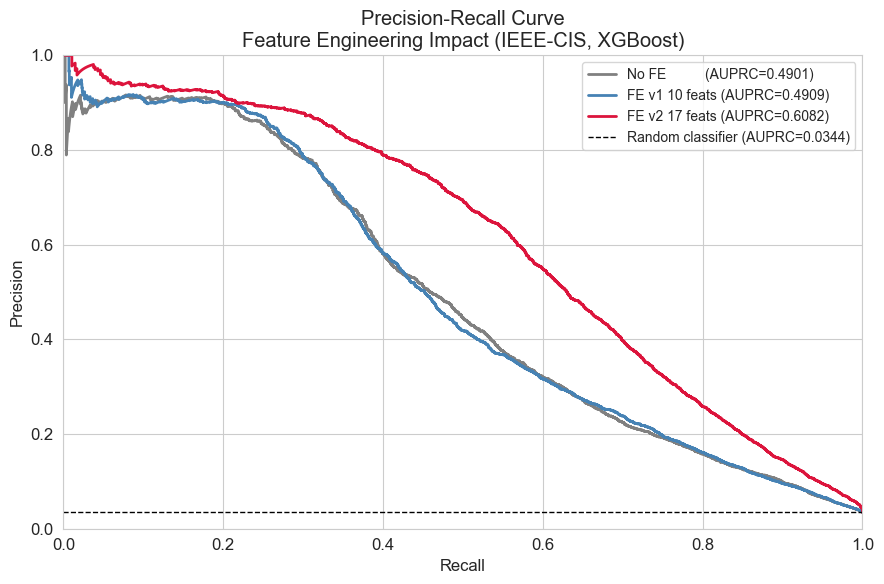


Baseline (random):              0.0344
Improvement A→C over random:   17.7x


In [17]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(9, 6))

for pred, label, color in [
    (pred_a, f'No FE          (AUPRC={auprc_a:.4f})', 'gray'),
    (pred_b, f'FE v1 10 feats (AUPRC={auprc_b:.4f})', 'steelblue'),
    (pred_c, f'FE v2 17 feats (AUPRC={auprc_c:.4f})', 'crimson'),
]:
    precision, recall, _ = precision_recall_curve(y_test, pred)
    ax.plot(recall, precision, color=color, linewidth=2, label=label)

baseline = y_test.mean()
ax.axhline(y=baseline, color='black', linestyle='--', linewidth=1,
           label=f'Random classifier (AUPRC={baseline:.4f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve\nFeature Engineering Impact (IEEE-CIS, XGBoost)')
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'data' / 'processed' / 'pr_curve_fe_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBaseline (random):              {baseline:.4f}")
print(f"Improvement A→C over random:   {auprc_c/baseline:.1f}x")



In [18]:
# 找一个在 train 和 test 里都出现的 uid
uid_in_both = (
    set(ieee_train_fe['uid'].unique()) & 
    set(ieee_test_fe['uid'].unique())
)
print(f"UIDs appearing in both train and test: {len(uid_in_both):,}")

# 取一个具体的 uid 来检查
sample_uid = list(uid_in_both)[0]

# 在完整数据里找这个 uid 的所有记录
uid_rows = df_all_ieee[df_all_ieee['uid'] == sample_uid][
    ['TransactionDT', 'isFraud', 'uid_fraud_mean']
].reset_index(drop=True)

print(f"\nSample uid: {sample_uid}")
print(uid_rows.to_string())

# 关键检查：test 里第一笔的 uid_fraud_mean
# 应该等于 train 里所有该 uid 交易的历史欺诈均值
train_uid_fraud = ieee_train_fe[ieee_train_fe['uid'] == sample_uid]['isFraud'].mean()
test_first_fraud_mean = ieee_test_fe[
    ieee_test_fe['uid'] == sample_uid
]['uid_fraud_mean'].iloc[0]

print(f"\nTrain fraud rate for this uid: {train_uid_fraud:.4f}")
print(f"Test first row uid_fraud_mean: {test_first_fraud_mean:.4f}")
print(f"Match: {'✓' if abs(train_uid_fraud - test_first_fraud_mean) < 0.001 else '✗ LEAKAGE DETECTED'}")

UIDs appearing in both train and test: 12,984

Sample uid: 12133_264.0
    TransactionDT  isFraud  uid_fraud_mean
0         1057039        0             0.0
1         1466955        0             0.0
2         2054013        0             0.0
3         2827691        0             0.0
4         3799238        0             0.0
5         3800671        0             0.0
6         8894500        0             0.0
7         9753509        0             0.0
8        10342385        0             0.0
9        10346414        0             0.0
10       15610705        0             0.0
11       15610745        0             0.0
12       15805844        0             0.0

Train fraud rate for this uid: 0.0000
Test first row uid_fraud_mean: 0.0000
Match: ✓


In [19]:
# ── 找一个在 train 里有欺诈、在 test 里也出现的 uid ──────
uid_in_both = (
    set(ieee_train_fe['uid'].unique()) &
    set(ieee_test_fe['uid'].unique())
)
fraud_uids_in_train = set(
    ieee_train_fe[ieee_train_fe['isFraud']==1]['uid'].unique()
)
uid_fraud_and_both = fraud_uids_in_train & uid_in_both
print(f"UIDs with fraud in train AND appearing in test: {len(uid_fraud_and_both):,}")

# ── 取一个具体 uid 检查 ───────────────────────────────────
sample_uid = list(uid_fraud_and_both)[0]
split_dt   = ieee_test_fe['TransactionDT'].min()

uid_rows = df_all_ieee[df_all_ieee['uid'] == sample_uid][
    ['TransactionDT', 'isFraud', 'uid_fraud_mean']
].reset_index(drop=True)
uid_rows['set'] = uid_rows['TransactionDT'].apply(
    lambda x: 'TEST' if x >= split_dt else 'TRAIN'
)

print(f"\nSample uid: {sample_uid}")
print(uid_rows.to_string())

# ── 核心验证：逐行检查 uid_fraud_mean 是否只看过去 ─────────
print("\n=== Row-by-row leakage check ===")
all_pass = True
for i in range(len(uid_rows)):
    row       = uid_rows.iloc[i]
    # 正确期望：只用第 0 到 i-1 行的 isFraud 均值
    if i == 0:
        expected = 0.0
    else:
        expected = uid_rows.iloc[:i]['isFraud'].mean()
    actual = row['uid_fraud_mean']
    match  = abs(expected - actual) < 0.001
    status = '✓' if match else '✗ LEAKAGE'
    if not match:
        all_pass = False
    print(f"  Row {i:2d} [{row['set']:5s}] isFraud={int(row['isFraud'])}  "
          f"expected={expected:.4f}  actual={actual:.4f}  {status}")

print()
if all_pass:
    print("✓ ALL ROWS PASS — uid_fraud_mean contains NO leakage")
else:
    print("✗ LEAKAGE DETECTED — needs fixing")

UIDs with fraud in train AND appearing in test: 1,826

Sample uid: 11965_-1.0
    TransactionDT  isFraud  uid_fraud_mean    set
0          327939        0        0.000000  TRAIN
1         1383803        1        0.000000  TRAIN
2         1535557        0        0.500000  TRAIN
3         1545187        0        0.333333  TRAIN
4         1545368        0        0.250000  TRAIN
5         1545464        0        0.200000  TRAIN
6         1545922        0        0.166667  TRAIN
7         1546112        0        0.142857  TRAIN
8         1546228        0        0.125000  TRAIN
9         1546430        0        0.111111  TRAIN
10        1546548        0        0.100000  TRAIN
11        1546736        0        0.090909  TRAIN
12        1553051        0        0.083333  TRAIN
13        1553573        0        0.076923  TRAIN
14        1554867        0        0.071429  TRAIN
15        1555031        0        0.066667  TRAIN
16        3088755        0        0.062500  TRAIN
17        3118697     

In [20]:
import json
from pathlib import Path

processed_dir = Path.cwd().parent / 'data' / 'processed'

# 保存带 v2 特征的数据
ieee_train_fe.to_parquet(processed_dir / 'ieee_train.parquet', index=False)
ieee_test_fe.to_parquet(processed_dir  / 'ieee_test.parquet',  index=False)

# 更新 dataset_info.json
dataset_info = {
    'ieee': {
        'engineered_features': engineered_features_v2,
        'raw_features': raw_features_enc,
        'target': 'isFraud',
        'time_col': 'TransactionDT',
        'train_rows': len(ieee_train_fe),
        'test_rows': len(ieee_test_fe),
        'train_fraud_rate': round(ieee_train_fe['isFraud'].mean(), 5),
        'test_fraud_rate': round(ieee_test_fe['isFraud'].mean(), 5),
        'auprc_no_fe': round(auprc_a, 4),
        'auprc_fe_v1': round(auprc_b, 4),
        'auprc_fe_v2': round(auprc_c, 4),
    },
    'paysim': {
        'engineered_features': paysim_features,
        'target': 'isFraud',
        'time_col': 'step',
        'train_rows': len(paysim_train_fe),
        'test_rows': len(paysim_test_fe),
        'train_fraud_rate': round(paysim_train_fe['isFraud'].mean(), 5),
        'test_fraud_rate': round(paysim_test_fe['isFraud'].mean(), 5),
    }
}

with open(processed_dir / 'dataset_info.json', 'w') as f:
    json.dump(dataset_info, f, indent=2)

print("=== Saved Files ===")
for f in sorted(processed_dir.iterdir()):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"  {f.name:35s} {size_mb:.1f} MB")

print("\n=== AUPRC Summary (for report) ===")
print(f"  No feature engineering:    {auprc_a:.4f}")
print(f"  FE v1 (10 features):       {auprc_b:.4f}  (+{auprc_b-auprc_a:.4f})")
print(f"  FE v2 (17 features):       {auprc_c:.4f}  (+{auprc_c-auprc_a:.4f}, +{(auprc_c/auprc_a-1)*100:.1f}%)")

=== Saved Files ===
  dataset_info.json                   0.0 MB
  ieee_test.parquet                   26.3 MB
  ieee_train.parquet                  93.2 MB
  paysim_test.parquet                 71.1 MB
  paysim_train.parquet                277.7 MB
  pr_curve_fe_comparison.png          0.1 MB

=== AUPRC Summary (for report) ===
  No feature engineering:    0.4901
  FE v1 (10 features):       0.4909  (+0.0008)
  FE v2 (17 features):       0.6082  (+0.1181, +24.1%)
